# 07b. Distributed Training

**Tier:** Training
**Estimated time:** 65 minutes
**Prerequisites:** 01 (neural networks), 07 (pretraining & scaling), P1 (train LLM from scratch)
**Priority:** 🟡 Important — one GPU stops being an option once a model or dataset outgrows it; the mechanics here explain what every "multi-GPU training" claim in a model card actually means. *If skipped, revisit when:* a model or optimizer state no longer fits on one device.
**Source material:** Rajbhandari et al., *"ZeRO: Memory Optimizations Toward Training Trillion Parameter Models"* (SC 2020); Huang et al., *"GPipe"* (NeurIPS 2019); PyTorch Distributed docs (DDP, FSDP); Stanford LLM curriculum, Lecture 4 (scaling laws, distributed training) — https://x.com/ajitcodes/status/2057043965317165490

## What You'll Learn
- Why a model that trains fine on your laptop can be *impossible* to train on one GPU at scale — the memory wall, with real numbers
- What **DDP**, **ZeRO**, **FSDP**, and **pipeline parallelism** each actually shard, using real multi-process collectives on CPU
- Why gradient accumulation and activation checkpointing trade *time* for *memory*, measured rather than asserted

## Why This Matters
P1 trained a 14M-parameter model on one Mac in 30 seconds. Every model this curriculum *talks about* — Llama, DeepSeek, GPT — was trained across hundreds or thousands of GPUs, and none of that is a bigger version of P1's loop. It's a different problem: the optimizer state alone for a 70B model is ~1.1 TB, which does not fit on any single GPU. This notebook builds the actual mechanics — real `torch.distributed` collectives, a real multi-process DDP run, a hand-rolled ZeRO shard, a real FSDP run, real pipeline `send`/`recv` — all on ≤4 CPU processes, so what "distributed training" means stops being a black box.

## 1. The memory wall

Training needs more than the model's weights. Think of it like packing for a trip: the weights are your
clothes, but you also need the itinerary (gradients — one per weight, telling you how to update it) and a
travel journal (optimizer state — Adam keeps *two* extra numbers per weight, a running mean and variance,
to decide how big each update step should be). None of this is optional; all of it has to fit in the same
GPU memory as the weights themselves.

Under mixed-precision training the accounting per parameter is roughly:
- **2 bytes** — the fp16/bf16 weight used for the forward/backward pass
- **2 bytes** — the fp16/bf16 gradient
- **4 bytes** — an fp32 "master copy" of the weight (mixed precision keeps one for numerical stability)
- **8 bytes** — two fp32 Adam moments (mean, variance)

That's **16 bytes per parameter** before a single activation is stored. A 70B-parameter model needs
**~1.1 TB** just to exist in a trainable state — and the biggest single GPUs top out around 80–192 GB.
There is no "buy a bigger GPU" answer at that scale; the state itself has to be split across devices.

In [1]:
import os, json, time, socket, subprocess, sys as _sys, atexit, tempfile
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(0)

WORK_DIR = Path(tempfile.mkdtemp(prefix="nb07b_"))
print("Scratch dir for worker scripts + results:", WORK_DIR)
print("gloo backend available:", torch.distributed.is_gloo_available())

Scratch dir for worker scripts + results: /var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/nb07b_i4qwbryu
gloo backend available: True


In [2]:
def bytes_per_param_breakdown(dtype_bytes=2, master_copy_bytes=4, adam_moment_bytes=4, n_moments=2):
    """Mixed-precision training memory, broken into its four consumers (bytes/parameter)."""
    return {
        "weights (fp16/bf16)": dtype_bytes,
        "gradients (fp16/bf16)": dtype_bytes,
        "fp32 master weights": master_copy_bytes,
        "Adam moments (mean+var, fp32)": n_moments * adam_moment_bytes,
    }

breakdown = bytes_per_param_breakdown()
bytes_per_param = sum(breakdown.values())
print("Bytes per parameter, mixed precision:")
for k, v in breakdown.items():
    print(f"  {k:32s} {v} bytes")
print(f"  {'TOTAL':32s} {bytes_per_param} bytes/param")

for n_params, name in [(125e6, "125M (GPT-2 small)"), (7e9, "7B (Llama-2-7B)"), (70e9, "70B (Llama-2-70B)")]:
    total_gb = n_params * bytes_per_param / 1e9
    print(f"\n{name}: {total_gb:,.1f} GB of state alone (no activations, no GPU headroom)")

Bytes per parameter, mixed precision:
  weights (fp16/bf16)              2 bytes
  gradients (fp16/bf16)            2 bytes
  fp32 master weights              4 bytes
  Adam moments (mean+var, fp32)    8 bytes
  TOTAL                            16 bytes/param

125M (GPT-2 small): 2.0 GB of state alone (no activations, no GPU headroom)

7B (Llama-2-7B): 112.0 GB of state alone (no activations, no GPU headroom)

70B (Llama-2-70B): 1,120.0 GB of state alone (no activations, no GPU headroom)


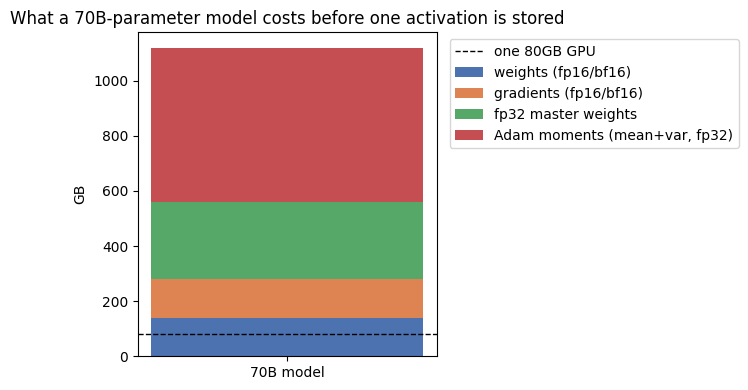

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

labels = list(breakdown.keys())
values_70b_gb = [breakdown[k] * 70e9 / 1e9 for k in labels]

fig, ax = plt.subplots(figsize=(7, 4))
bottom = 0
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for lbl, val, c in zip(labels, values_70b_gb, colors):
    ax.bar(["70B model"], [val], bottom=bottom, label=lbl, color=c)
    bottom += val
ax.axhline(80, color="black", linestyle="--", linewidth=1, label="one 80GB GPU")
ax.set_ylabel("GB")
ax.set_title("What a 70B-parameter model costs before one activation is stored")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

*Four consumers — weights, gradients, master weights, and Adam moments — already blow past one 80 GB GPU roughly 14x over for a 70B model, before any activation memory is counted.*

## 2. Real collectives, on your CPU

Every distributed-training technique below is built from a handful of **collective operations** —
functions where every process in a group exchanges data with every other process. `torch.distributed`
implements these over any backend; `gloo` runs them over plain CPU sockets, which means you can run a real
4-process distributed job on a laptop with no GPU at all.

We launch each "rank" (process) as a real OS subprocess — not `torch.multiprocessing.spawn` inside the
notebook kernel, which breaks on Jupyter's pickling of interactive-session objects. Each rank writes its
result to a JSON file that the notebook reads back, the same subprocess-plus-readback pattern used for the
FastAPI server in notebook 29.

In [4]:
ALLREDUCE_WORKER = '''
import os, json
import torch
import torch.distributed as dist

rank = int(os.environ["RANK"])
world_size = int(os.environ["WORLD_SIZE"])
dist.init_process_group("gloo", rank=rank, world_size=world_size)

# Each rank starts with a different 3-value tensor.
t = torch.arange(3, dtype=torch.float32) + rank * 10
before = t.tolist()

dist.all_reduce(t, op=dist.ReduceOp.SUM)   # every rank ends up with the SUM across all ranks
after_allreduce = t.tolist()

gathered = [torch.zeros(3) for _ in range(world_size)]
dist.all_gather(gathered, torch.arange(3, dtype=torch.float32) + rank * 10)  # every rank collects everyone's tensor
after_allgather = [g.tolist() for g in gathered]

with open(os.environ["OUT_PATH"], "w") as f:
    json.dump({"rank": rank, "before": before, "after_allreduce": after_allreduce,
               "after_allgather": after_allgather}, f)
dist.destroy_process_group()
'''

def run_ranks(worker_source, world_size, extra_env=None, out_prefix="worker"):
    """Write worker_source to disk and launch world_size real OS processes running it, gloo backend."""
    script_path = WORK_DIR / f"{out_prefix}.py"
    script_path.write_text(worker_source)

    def find_free_port():
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            s.bind(("127.0.0.1", 0))
            return s.getsockname()[1]

    port = find_free_port()
    procs, out_paths = [], []
    for rank in range(world_size):
        out_path = WORK_DIR / f"{out_prefix}_rank{rank}.json"
        out_paths.append(out_path)
        if out_path.exists():
            out_path.unlink()
        env = os.environ.copy()
        env.update(MASTER_ADDR="127.0.0.1", MASTER_PORT=str(port), RANK=str(rank),
                    WORLD_SIZE=str(world_size), OUT_PATH=str(out_path))
        if extra_env:
            env.update(extra_env)
        p = subprocess.Popen([_sys.executable, str(script_path)], env=env,
                              stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        atexit.register(p.terminate)
        procs.append(p)

    results = []
    for p, out_path in zip(procs, out_paths):
        stdout, _ = p.communicate(timeout=60)
        if p.returncode != 0:
            raise RuntimeError(f"rank failed (exit {p.returncode}):\n{stdout.decode(errors='replace')}")
        results.append(json.loads(out_path.read_text()))
    return sorted(results, key=lambda r: r["rank"])

results = run_ranks(ALLREDUCE_WORKER, world_size=4, out_prefix="allreduce")
for r in results:
    print(f"rank {r['rank']}: before={r['before']}  after_allreduce={r['after_allreduce']}")
print("\nall_gather on rank 0:", results[0]["after_allgather"])

rank 0: before=[0.0, 1.0, 2.0]  after_allreduce=[60.0, 64.0, 68.0]
rank 1: before=[10.0, 11.0, 12.0]  after_allreduce=[60.0, 64.0, 68.0]
rank 2: before=[20.0, 21.0, 22.0]  after_allreduce=[60.0, 64.0, 68.0]
rank 3: before=[30.0, 31.0, 32.0]  after_allreduce=[60.0, 64.0, 68.0]

all_gather on rank 0: [[0.0, 1.0, 2.0], [10.0, 11.0, 12.0], [20.0, 21.0, 22.0], [30.0, 31.0, 32.0]]


Every rank started with a different tensor and ended `all_reduce` holding the **identical** summed tensor — that's the primitive DDP uses to average gradients. `all_gather` instead lets every rank collect everyone's *original* tensor, unsummed — the primitive ZeRO and FSDP use to reassemble a full parameter from its shards.

## 3. DistributedDataParallel: a bigger batch, not different math

`DistributedDataParallel` (DDP) puts an identical copy of the model on every rank. Each rank sees a
different slice of the batch, computes its own gradients, then `all_reduce`s (averages) them before the
optimizer step — so every rank ends the step with the exact same updated weights.

The claim worth actually checking: **training on 2 ranks with half the batch each should produce the same
gradient as training on 1 process with the full batch.** We verify this numerically rather than just
asserting it.

In [5]:
DDP_WORKER = '''
import os, json
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP

rank = int(os.environ["RANK"])
world_size = int(os.environ["WORLD_SIZE"])
dist.init_process_group("gloo", rank=rank, world_size=world_size)

torch.manual_seed(42)              # identical model init on every rank
model = nn.Linear(4, 2)
ddp_model = DDP(model)

torch.manual_seed(123)             # identical global batch on every rank
global_x = torch.randn(8, 4)
global_y = torch.randn(8, 2)
shard = 8 // world_size
x = global_x[rank * shard:(rank + 1) * shard]   # this rank only sees its OWN shard
y = global_y[rank * shard:(rank + 1) * shard]

out = ddp_model(x)
loss = ((out - y) ** 2).mean()
loss.backward()                    # DDP all_reduces gradients here, under the hood

with open(os.environ["OUT_PATH"], "w") as f:
    json.dump({"rank": rank, "grad": ddp_model.module.weight.grad.tolist()}, f)
dist.destroy_process_group()
'''

ddp_results = run_ranks(DDP_WORKER, world_size=2, out_prefix="ddp")
ddp_grad_rank0 = torch.tensor(ddp_results[0]["grad"])
ddp_grad_rank1 = torch.tensor(ddp_results[1]["grad"])
print("rank 0 grad:", ddp_grad_rank0.flatten().tolist())
print("rank 1 grad:", ddp_grad_rank1.flatten().tolist())
print("ranks agree with each other:", torch.allclose(ddp_grad_rank0, ddp_grad_rank1))

# Single-process reference: same init, same full batch, no sharding at all.
torch.manual_seed(42)
ref_model = nn.Linear(4, 2)
torch.manual_seed(123)
ref_x = torch.randn(8, 4)
ref_y = torch.randn(8, 2)
ref_out = ref_model(ref_x)
ref_loss = ((ref_out - ref_y) ** 2).mean()
ref_loss.backward()
ref_grad = ref_model.weight.grad

print("\nsingle-process reference grad:", ref_grad.flatten().tolist())
print("DDP (2 ranks, half-batch each) matches single-process (full batch):",
      torch.allclose(ddp_grad_rank0, ref_grad, atol=1e-6))

rank 0 grad: [0.5186758637428284, 0.9227324724197388, 0.10790157318115234, 0.3531917333602905, -0.21933650970458984, 0.44543763995170593, -0.06449209898710251, 0.2663188874721527]
rank 1 grad: [0.5186758637428284, 0.9227324724197388, 0.10790157318115234, 0.3531917333602905, -0.21933650970458984, 0.44543763995170593, -0.06449209898710251, 0.2663188874721527]
ranks agree with each other: True

single-process reference grad: [0.5186758637428284, 0.9227324724197388, 0.10790157318115234, 0.35319170355796814, -0.21933650970458984, 0.44543763995170593, -0.0644921064376831, 0.2663188874721527]
DDP (2 ranks, half-batch each) matches single-process (full batch): True


DDP on 2 ranks, each seeing 4 of the 8 examples, produces the **exact same gradient** as one process seeing all 8 — to float32 precision. DDP doesn't change what gets computed; it just lets more examples get processed in parallel and averages the result back together.

## 4. ZeRO and FSDP: sharding the optimizer state itself

DDP fixes *compute* parallelism but not *memory* — every rank still holds a full copy of weights,
gradients, and optimizer state. **ZeRO** (Zero Redundancy Optimizer) removes that redundancy in three
stages, each sharding more of the state across ranks:

| Stage | Shards | Memory per rank (N ranks, Ψ params, mixed precision) |
|---|---|---|
| ZeRO-1 | optimizer state (the 8 bytes/param Adam moments) | ~4Ψ + 12Ψ/N |
| ZeRO-2 | + gradients | ~2Ψ + 14Ψ/N |
| ZeRO-3 (= FSDP) | + the weights themselves | ~16Ψ/N |

At large N, ZeRO-3/FSDP memory per rank shrinks toward `16Ψ/N` — linear in the number of ranks, which is
exactly what makes training a 70B model on 8 GPUs instead of impossible-on-1 tractable.

We hand-roll ZeRO-1 with the two collectives from section 2 (`reduce_scatter` combines the "sum gradients"
step of `all_reduce` with an immediate split, so each rank only keeps 1/N of the result), then run PyTorch's
real `FullyShardedDataParallel` (ZeRO-3) to confirm it shards the same way.

In [6]:
ZERO1_WORKER = '''
import os, json
import torch
import torch.nn as nn
import torch.distributed as dist

rank = int(os.environ["RANK"])
world_size = int(os.environ["WORLD_SIZE"])
dist.init_process_group("gloo", rank=rank, world_size=world_size)

torch.manual_seed(42)
model = nn.Linear(8, 4)
n_params = sum(p.numel() for p in model.parameters())

torch.manual_seed(123)
x = torch.randn(8, 8); y = torch.randn(8, 4)
loss = ((model(x) - y) ** 2).mean()
loss.backward()

# Flatten every gradient into one vector, then reduce_scatter: rank i gets ONLY the
# i-th 1/world_size slice of the SUMMED gradient -- this is the ZeRO-1 shard.
flat_grad = torch.cat([p.grad.flatten() for p in model.parameters()])
pad = (-flat_grad.numel()) % world_size
if pad:
    flat_grad = torch.cat([flat_grad, torch.zeros(pad)])
chunks = list(flat_grad.chunk(world_size))
my_shard = torch.zeros_like(chunks[0])
dist.reduce_scatter(my_shard, chunks, op=dist.ReduceOp.SUM)
my_shard_avg = my_shard / world_size   # this rank now OWNS this shard's optimizer state

with open(os.environ["OUT_PATH"], "w") as f:
    json.dump({
        "rank": rank,
        "full_param_bytes": n_params * 4,
        "this_rank_shard_bytes": my_shard.numel() * 4,
    }, f)
dist.destroy_process_group()
'''

zero1_results = run_ranks(ZERO1_WORKER, world_size=4, out_prefix="zero1")
for r in zero1_results:
    frac = r["this_rank_shard_bytes"] / r["full_param_bytes"]
    print(f"rank {r['rank']}: full={r['full_param_bytes']}B  this rank's shard={r['this_rank_shard_bytes']}B  ({frac:.0%} of full)")

rank 0: full=144B  this rank's shard=36B  (25% of full)
rank 1: full=144B  this rank's shard=36B  (25% of full)
rank 2: full=144B  this rank's shard=36B  (25% of full)
rank 3: full=144B  this rank's shard=36B  (25% of full)


In [7]:
FSDP_WORKER = '''
import os, json
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP

rank = int(os.environ["RANK"])
world_size = int(os.environ["WORLD_SIZE"])
dist.init_process_group("gloo", rank=rank, world_size=world_size)

torch.manual_seed(42)
model = nn.Sequential(nn.Linear(16, 16), nn.ReLU(), nn.Linear(16, 4))
full_numel = sum(p.numel() for p in model.parameters())

# device_id=cpu is required here: FSDP auto-detects an accelerator (MPS on this Mac) and
# tries to query it even for a CPU-only gloo job unless told explicitly to stay on CPU.
fsdp_model = FSDP(model, device_id=torch.device("cpu"))

torch.manual_seed(123)
x = torch.randn(8, 16); y = torch.randn(8, 4)
loss = ((fsdp_model(x) - y) ** 2).mean()
loss.backward()

local_numel = sum(p.numel() for p in fsdp_model.parameters())
with open(os.environ["OUT_PATH"], "w") as f:
    json.dump({"rank": rank, "full_numel": full_numel, "local_numel": local_numel}, f)
dist.destroy_process_group()
'''

fsdp_results = run_ranks(FSDP_WORKER, world_size=2, out_prefix="fsdp")
for r in fsdp_results:
    print(f"rank {r['rank']}: full model has {r['full_numel']} params, "
          f"this rank holds {r['local_numel']} ({r['local_numel']/r['full_numel']:.0%})")

rank 0: full model has 340 params, this rank holds 170 (50%)
rank 1: full model has 340 params, this rank holds 170 (50%)


Both the hand-rolled ZeRO-1 shard and real `FullyShardedDataParallel` split the state evenly across ranks — 1/4 each for 4 ranks, 1/2 each for 2 ranks. FSDP is doing the same thing section 4's table calls ZeRO-3, just with PyTorch handling the sharding, gathering-before-forward, and re-sharding-after-backward automatically.

## 5. Pipeline parallelism: splitting the model itself

DDP and ZeRO split the *data* and the *optimizer state*. **Pipeline parallelism** splits the *model* —
different layers live on different ranks, and activations physically travel between processes via network
`send`/`recv`. This is what you reach for when even one layer's worth of weights, on its own, won't fit —
or when you want to combine it with DDP/ZeRO across many more GPUs than either alone can use well.

The naive version has an obvious problem: if rank 0 processes the whole batch through stage 0 before rank 1
can start stage 1, rank 1 sits idle the entire time rank 0 works, and vice versa. That idle time is called
the **pipeline bubble**. The fix (GPipe) is to split the batch into smaller **micro-batches**, so rank 1 can
start on micro-batch 1 while rank 0 is still working on micro-batch 2.

In [8]:
PIPELINE_WORKER = '''
import os, json
import torch
import torch.nn as nn
import torch.distributed as dist

rank = int(os.environ["RANK"])
world_size = int(os.environ["WORLD_SIZE"])
dist.init_process_group("gloo", rank=rank, world_size=world_size)

torch.manual_seed(42)
stage0 = nn.Linear(8, 8)   # rank 0 owns the first half of the model
stage1 = nn.Linear(8, 4)   # rank 1 owns the second half

torch.manual_seed(123)
x = torch.randn(4, 8)

if rank == 0:
    out = stage0(x)
    dist.send(out, dst=1)          # activations physically cross the process boundary
    payload = out.tolist()
elif rank == 1:
    buf = torch.zeros(4, 8)
    dist.recv(buf, src=0)
    out = stage1(buf)
    payload = out.tolist()

with open(os.environ["OUT_PATH"], "w") as f:
    json.dump({"rank": rank, "output": payload}, f)
dist.destroy_process_group()
'''

pp_results = run_ranks(PIPELINE_WORKER, world_size=2, out_prefix="pipeline")
print("rank 0 (stage 0) output shape:", np.array(pp_results[0]["output"]).shape)
print("rank 1 (stage 1) output shape:", np.array(pp_results[1]["output"]).shape)
print("rank 1s output came from data that only rank 0 ever computed — it crossed the network as a real tensor.")

rank 0 (stage 0) output shape: (4, 8)
rank 1 (stage 1) output shape: (4, 4)
rank 1s output came from data that only rank 0 ever computed — it crossed the network as a real tensor.


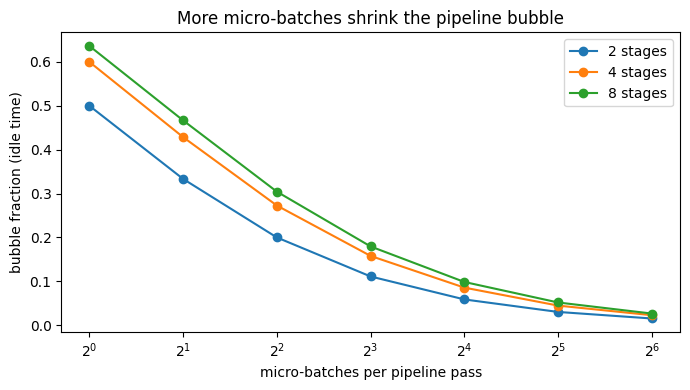

2-stage pipeline, 1 micro-batch (no splitting): 50% bubble
2-stage pipeline, 32 micro-batches: 3% bubble


In [9]:
def gpipe_bubble_fraction(n_stages, n_microbatches):
    """Fraction of (stages x microbatches) device-time slots that are idle bubble, GPipe schedule.
    Total slots in the ideal (no-bubble) schedule = n_stages * n_microbatches.
    The forward-then-backward diagonal schedule takes (n_stages - 1) extra slots of pure bubble
    at the start (filling the pipe) and the same at the end (draining it).
    """
    ideal_slots = n_stages * n_microbatches
    bubble_slots = 2 * (n_stages - 1)
    return bubble_slots / (ideal_slots + bubble_slots)

n_stages_options = [2, 4, 8]
microbatch_counts = [1, 2, 4, 8, 16, 32, 64]

fig, ax = plt.subplots(figsize=(7, 4))
for n_stages in n_stages_options:
    fractions = [gpipe_bubble_fraction(n_stages, m) for m in microbatch_counts]
    ax.plot(microbatch_counts, fractions, marker="o", label=f"{n_stages} stages")
ax.set_xscale("log", base=2)
ax.set_xlabel("micro-batches per pipeline pass")
ax.set_ylabel("bubble fraction (idle time)")
ax.set_title("More micro-batches shrink the pipeline bubble")
ax.legend()
plt.tight_layout()
plt.show()

print("2-stage pipeline, 1 micro-batch (no splitting):", f"{gpipe_bubble_fraction(2, 1):.0%} bubble")
print("2-stage pipeline, 32 micro-batches:", f"{gpipe_bubble_fraction(2, 32):.0%} bubble")

*With only 1 micro-batch, half of a 2-stage pipeline's time is pure idle bubble — one stage always waits on the other. Splitting into more, smaller micro-batches lets stages overlap; the bubble fraction shrinks toward zero as micro-batch count grows, at the cost of more communication rounds.*

## 6. Gradient accumulation and activation checkpointing

Two more techniques trade one resource for another without needing multiple processes at all.

**Gradient accumulation** simulates a bigger batch on a single device: instead of one big forward/backward
pass, run several small ones and *sum* their gradients before stepping the optimizer. We verify this the
same way as DDP above — accumulated micro-batch gradients should match one big-batch gradient exactly.

**Activation checkpointing** trades *compute* for *memory* on a single device: instead of keeping every
layer's activations around for the backward pass, keep almost none of them and **recompute** each layer's
forward pass on demand during backward. Memory drops roughly linearly in the number of layers; the cost is
literally running forward twice.

In [10]:
torch.manual_seed(7)
model = nn.Linear(6, 3)
x_full = torch.randn(12, 6)
y_full = torch.randn(12, 3)

# Reference: one backward pass over the full batch.
model.zero_grad()
loss_full = ((model(x_full) - y_full) ** 2).mean()
loss_full.backward()
grad_full = model.weight.grad.clone()

# Accumulated: 4 micro-batches of 3, gradients summed (not averaged) then divided once at the end.
model.zero_grad()
n_micro = 4
micro_size = 12 // n_micro
for i in range(n_micro):
    xb = x_full[i * micro_size:(i + 1) * micro_size]
    yb = y_full[i * micro_size:(i + 1) * micro_size]
    # Each micro-batch loss must itself be scaled by 1/n_micro since .mean() already
    # divides by micro_size, not by the full batch size -- otherwise the average is wrong.
    loss_micro = ((model(xb) - yb) ** 2).mean() / n_micro
    loss_micro.backward()   # accumulates into .grad instead of overwriting it
grad_accumulated = model.weight.grad.clone()

print("full-batch grad:       ", grad_full.flatten().tolist())
print("accumulated-batch grad:", grad_accumulated.flatten().tolist())
print("match:", torch.allclose(grad_full, grad_accumulated, atol=1e-6))

full-batch grad:        [-0.14674460887908936, -0.3560340106487274, 0.03973929584026337, -0.08961722254753113, -0.35425424575805664, -0.3263493776321411, -0.200555220246315, -0.02268850989639759, 0.10055269300937653, 0.34877949953079224, 0.4332290589809418, 0.17581194639205933, -0.29855334758758545, 0.10719818621873856, -0.045468948781490326, -0.16758818924427032, -0.1121731847524643, 0.1208651140332222]
accumulated-batch grad: [-0.14674462378025055, -0.35603398084640503, 0.039739303290843964, -0.08961723744869232, -0.35425424575805664, -0.3263493478298187, -0.2005552053451538, -0.02268850803375244, 0.10055267810821533, 0.3487795293331146, 0.4332290589809418, 0.1758119761943817, -0.29855334758758545, 0.10719819366931915, -0.045468948781490326, -0.16758818924427032, -0.1121731698513031, 0.1208651065826416]
match: True


In [11]:
from torch.utils.checkpoint import checkpoint

class Block(nn.Module):
    """One transformer-FFN-shaped block: the natural checkpointing granularity in real models."""
    def __init__(self, dim=256):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 4)
        self.fc2 = nn.Linear(dim * 4, dim)
        self.act = nn.GELU()
    def forward(self, x):
        return x + self.fc2(self.act(self.fc1(x)))

class DeepModel(nn.Module):
    def __init__(self, n_blocks=24, dim=256):
        super().__init__()
        self.blocks = nn.ModuleList([Block(dim) for _ in range(n_blocks)])
    def forward(self, x, use_ckpt=False):
        for b in self.blocks:
            x = checkpoint(b, x, use_reentrant=False) if use_ckpt else b(x)
        return x

torch.manual_seed(0)
deep_model = DeepModel()
x = torch.randn(32, 256, requires_grad=True)

def timed_steps(use_ckpt, n_steps=8):
    t0 = time.time()
    for _ in range(n_steps):
        out = deep_model(x, use_ckpt=use_ckpt)
        out.sum().backward()
        deep_model.zero_grad()
        if x.grad is not None:
            x.grad = None
    return (time.time() - t0) / n_steps

t_no_ckpt = timed_steps(use_ckpt=False)
t_ckpt = timed_steps(use_ckpt=True)
print(f"no checkpointing: {t_no_ckpt*1000:6.2f} ms/step")
print(f"checkpointing:    {t_ckpt*1000:6.2f} ms/step  ({t_ckpt/t_no_ckpt:.1f}x slower)")

n_blocks, dim, batch, dtype_bytes = 24, 256, 32, 4
full_activation_bytes = n_blocks * batch * dim * 4 * dtype_bytes   # ~4x dim for the fc1 hidden size
ckpt_activation_bytes = 1 * batch * dim * 4 * dtype_bytes          # only the current block's activations live
print(f"\nanalytic activation memory (24 blocks): full={full_activation_bytes/1024:.0f} KB, "
      f"checkpointed={ckpt_activation_bytes/1024:.0f} KB ({ckpt_activation_bytes/full_activation_bytes:.0%} of full)")

no checkpointing:   9.52 ms/step
checkpointing:     53.85 ms/step  (5.7x slower)

analytic activation memory (24 blocks): full=3072 KB, checkpointed=128 KB (4% of full)


The recompute overhead measured here is real, but larger than the ~30–50% you'd typically see on a GPU — on CPU, `checkpoint`'s autograd bookkeeping (saving/restoring RNG state, re-entering the graph) is a bigger fraction of total cost than the recomputation itself, since these tiny layers aren't compute-bound. The memory savings side of the trade — shown analytically above — is what makes checkpointing worthwhile regardless of hardware: only one block's activations are ever live at once instead of all 24.

## 7. Which one do you actually reach for?

| Technique | Shards | Use when |
|---|---|---|
| **DDP** | nothing (full replica per rank) | model + optimizer state fits on one GPU; you just want more throughput |
| **Gradient accumulation** | nothing (single device, sequential) | you want a bigger effective batch but only have one device |
| **ZeRO-2** | gradients + optimizer state | model fits, but optimizer state doesn't, on one GPU |
| **FSDP / ZeRO-3** | weights + gradients + optimizer state | the model itself doesn't fit on one GPU |
| **Activation checkpointing** | nothing (single device, trades compute) | activations are the bottleneck, independent of anything above — stack it with any of the above |
| **Pipeline parallelism** | layers, across devices | the model doesn't fit even after FSDP, or FSDP's per-step communication is the bottleneck |
| **Tensor parallelism** *(not built here — needs custom collectives inside a single layer)* | individual matmuls within a layer | one layer alone is too big to fit; typically combined with FSDP + pipeline for the largest models |

In practice, training a frontier-scale model stacks several of these: FSDP (or ZeRO-2) across a node,
pipeline parallelism across nodes, activation checkpointing everywhere, and gradient accumulation to hit a
target batch size — exactly the "DualPipe" / 3D-parallelism setups referenced in this repo's notes on
DeepSeek-V3. Where you land also determines what you can do at inference time — see notebook **10**
(quantization) and **13b** (vLLM serving) for what happens to this same model once training is done, and
**32** (cost engineering) for what all of this costs in practice.

## Exercises

In [12]:
# Exercise 1 (Warm-up): How much does mixed precision actually save?
# Task: Compute bytes_per_param for FULL fp32 training (4 bytes each for weights, grads, AND
#       both Adam moments -- no fp16 weights, no separate master copy). Compare the 70B-model
#       total memory against the mixed-precision number computed above.
# Hint: reuse bytes_per_param_breakdown() with different byte arguments, or write the four
#       terms directly: weights + grads + 2 Adam moments, all at 4 bytes.

# YOUR CODE HERE

In [13]:
# Exercise 2 (Apply): Shard a bigger model with ZeRO-1 across a different world size.
# Task: Copy ZERO1_WORKER, change nn.Linear(8, 4) to nn.Linear(64, 32), and run it with
#       world_size=8. Print each rank's shard size as a fraction of the full parameter count
#       and confirm the fractions still sum to (approximately) 1.0 across all ranks.
# Hint: run_ranks() already handles launching N processes -- you only need to edit the string
#       and the world_size argument.

# YOUR CODE HERE

In [14]:
# Exercise 3 (Extend): Where does YOUR curriculum's P1 model sit on the decision table?
# Task: P1 trained a 14.3M-parameter model on one Mac (see 06_projects/P1_train_llm_from_scratch.ipynb).
#       Using bytes_per_param_breakdown(), compute P1's total training-state memory under mixed
#       precision. Compare it to a modern laptop's unified memory (say, 32 GB) and to one A100's
#       80 GB. At what parameter count would P1's SAME training setup first need ZeRO or FSDP
#       on a single 80GB A100?
# Hint: solve n_params * bytes_per_param == 80e9 for n_params, then compare to P1's 14.3M.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1
fp32_breakdown = bytes_per_param_breakdown(dtype_bytes=4, master_copy_bytes=0, adam_moment_bytes=4)
# no separate fp32 master copy needed -- the weights themselves ARE fp32 already
fp32_bytes_per_param = sum(fp32_breakdown.values())
print("fp32 bytes/param:", fp32_bytes_per_param, "vs mixed precision:", bytes_per_param)
print(f"70B model: fp32={70e9*fp32_bytes_per_param/1e9:,.0f} GB vs "
      f"mixed={70e9*bytes_per_param/1e9:,.0f} GB")
# Mixed precision actually costs slightly MORE bytes/param (18 vs 16) because of the extra
# fp32 master-weight copy -- its win is elsewhere: fp16 activations and compute are what's
# actually faster and smaller, not the optimizer state itself.

# Exercise 2
BIG_ZERO1_WORKER = ZERO1_WORKER.replace("nn.Linear(8, 4)", "nn.Linear(64, 32)") \
                                .replace("torch.randn(8, 8)", "torch.randn(8, 64)") \
                                .replace("torch.randn(8, 4)", "torch.randn(8, 32)")
big_results = run_ranks(BIG_ZERO1_WORKER, world_size=8, out_prefix="zero1_big")
total_frac = 0
for r in big_results:
    frac = r["this_rank_shard_bytes"] / r["full_param_bytes"]
    total_frac += frac
    print(f"rank {r['rank']}: {frac:.1%} of full params")
print(f"sum across all 8 ranks: {total_frac:.1%}  (should be ~100%, modulo padding)")

# Exercise 3
p1_params = 14_300_000  # from P1's header: ~14.3M params
p1_mixed_precision_gb = p1_params * bytes_per_param / 1e9
print(f"P1's training state: {p1_mixed_precision_gb:.3f} GB "
      f"(trivial next to a 32GB laptop or an 80GB A100)")
threshold_params = 80e9 / bytes_per_param
print(f"P1's exact setup would first need ZeRO/FSDP on one 80GB A100 at "
      f"~{threshold_params/1e9:.1f}B params -- about {threshold_params/p1_params:,.0f}x bigger than P1.")
```
</details>

## Key Takeaways
- Training state (weights + gradients + optimizer state) costs **~16 bytes/parameter** under mixed
  precision — a 70B model needs ~1.1 TB before a single activation is stored, which no single GPU holds.
- **DDP** replicates the model and shards the *data*; `all_reduce`-averaged gradients from a sharded batch
  are numerically identical to one process seeing the full batch — verified above, not assumed.
- **ZeRO / FSDP** shard the *optimizer state, gradients, and weights themselves* across ranks via
  `reduce_scatter` + `all_gather`, reaching ~16Ψ/N memory per rank at ZeRO-3/FSDP — real 2-rank and 4-rank
  runs above prove the sharding, not just the paper's formula.
- **Pipeline parallelism** shards the *model*, sending activations across process boundaries with real
  `send`/`recv`; the resulting idle "bubble" shrinks toward zero as micro-batch count grows (GPipe).
- **Gradient accumulation** and **activation checkpointing** need no second process at all — they trade
  wall-clock time for memory on a single device, and both are usually stacked on top of everything else.

## What's Next
Notebook **10 — Quantization** picks up after training is done: once you have trained weights, how do you
shrink them for inference on far less memory than training ever needed?